In [9]:
import sys
import os

sys.path.append(os.path.abspath(".."))  

from src.torch_lightning.lightning_data_module import DroneDataModule

dm = DroneDataModule(
    root_dir="../data",
    dataset_type="binary",
    batch_size=4,
    num_workers=0
)

dm.setup()

loader = dm.train_dataloader()

for x, y in loader:
    print(x.shape)  # np. [4, 1, 128, T]
    print(y.shape)  # np. [4]
    break

[download_drone_audio.py] Downloading dataset from: https://codeload.github.com/saraalemadi/DroneAudioDataset/zip/refs/heads/master
[download_drone_audio.py] Saved zip to: ../data\DroneAudioDataset_master.zip
[download_drone_audio.py] Extracting zip to: ../data
Dataset root: ../data
Selected data dir: ../data\DroneAudioDataset-master\Binary_Drone_Audio
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
torch.Size([4, 1, 128, 126])
torch.Size([4])


Label: 0
Shape: torch.Size([1, 128, 126])


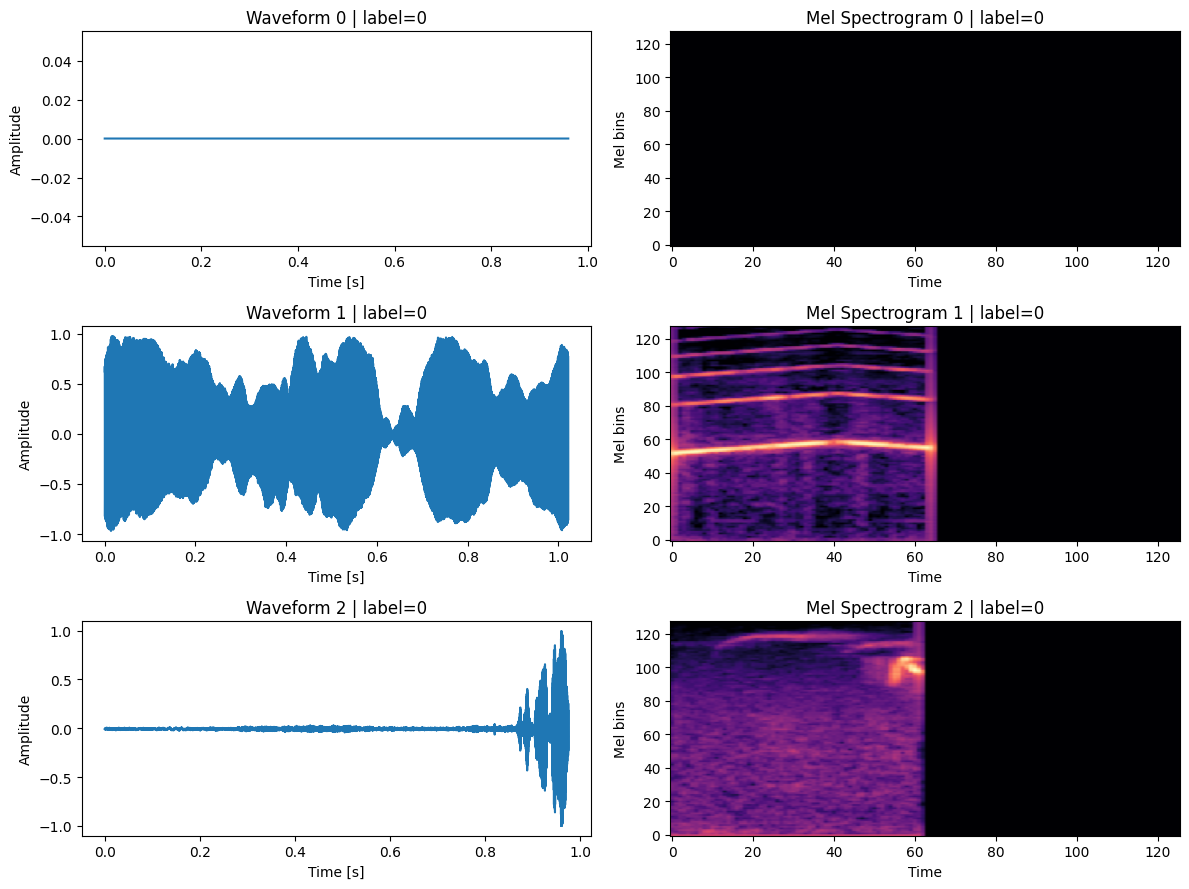

In [14]:
import matplotlib.pyplot as plt
import librosa
import numpy as np

dataset = dm.train_dataset

x, y = dataset[1]   

print("Label:", y.item())
print("Shape:", x.shape)  # [1, n_mels, T]

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

for i in range(3):
    audio_path = dataset.file_paths[i]
    label = dataset.labels[i]

    waveform, sr = librosa.load(audio_path, sr=None, mono=True)
    time_axis = np.arange(len(waveform)) / sr

    x, y = dataset[i]
    mel = x.squeeze(0).numpy()

    axes[i, 0].plot(time_axis, waveform)
    axes[i, 0].set_title(f"Waveform {i} | label={label}")
    axes[i, 0].set_xlabel("Time [s]")
    axes[i, 0].set_ylabel("Amplitude")

    axes[i, 1].imshow(mel, aspect='auto', origin='lower', cmap='magma')
    axes[i, 1].set_title(f"Mel Spectrogram {i} | label={y.item()}")
    axes[i, 1].set_xlabel("Time")
    axes[i, 1].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()